In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error , r2_score

In [14]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

In [19]:
X = data[['AveRooms']].values
Y = data['Price']

In [22]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2,random_state=42)

In [29]:
scaler= StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
w=0
b=0

learning_rate=0.09
epochs = 1000
cost_history =[]

n= len(X_train_scaled)

for i in range(epochs):
    Y_pred = w*X_train_scaled.flatten() +b
    cost = (1/(2*n)) * np.sum((Y_pred - Y_train) ** 2)
    cost_history.append(cost)
    dw = (1/n) * np.sum((Y_pred - Y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(Y_pred - Y_train)
    w = w -learning_rate * dw
    b = b - learning_rate * db

    if i % 100 ==0:
        
        print(f"Epoch {i}, Cost = {cost:.4f}")

        Y_pred_gd = w * X_test_scaled.flatten() +b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.6516
Epoch 200, Cost = 0.6516
Epoch 300, Cost = 0.6516
Epoch 400, Cost = 0.6516
Epoch 500, Cost = 0.6516
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [54]:
print("Gradient Descent")
print("----------------")
print("Weight:" , w)
print("Bias:" , b)
print("MSE:" , mean_squared_error(Y_test, Y_pred_gd))
print("R2 Score: " , r2_score(Y_test , Y_pred_gd))

Gradient Descent
----------------
Weight: 0.18323881713491483
Bias: 2.0719469373788737
MSE: 1.2923314440807299
R2 Score:  0.013795337532284901


In [51]:
X_train_ne = np.c_[np.ones((len(X_train),1)) , X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)) , X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ Y_train

Y_pred_ne  = X_test_ne @ theta

In [55]:
print("\nNormal Equation")
print("-----------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:" ,mean_squared_error(Y_test , Y_pred_ne))
print("R2 Score:" , r2_score(Y_test , Y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


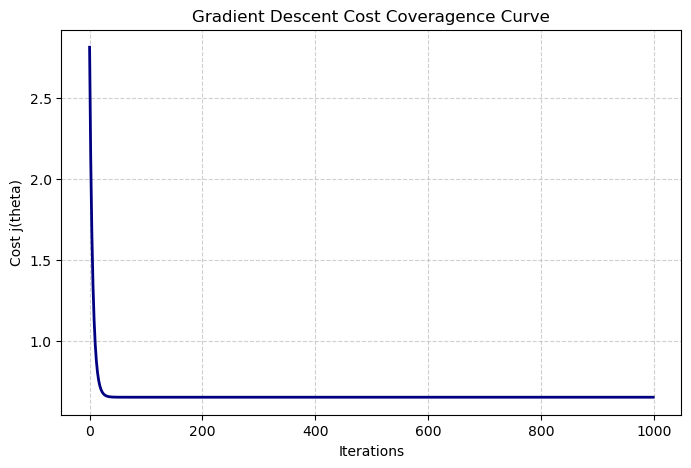

In [57]:
plt.figure(figsize=(8,5))

plt.plot(cost_history , color="navy" , linewidth=2)

plt.title('Gradient Descent Cost Coveragence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost j(theta)')
plt.grid(True, linestyle='--',alpha=0.6)

plt.show()

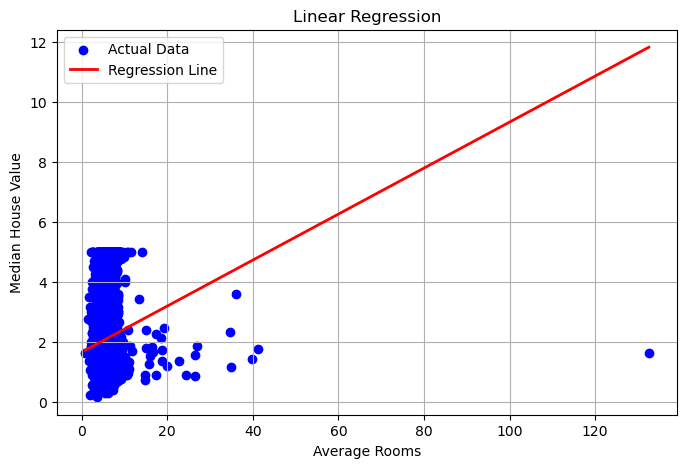

In [59]:
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))

plt.scatter(X_test, Y_test, color='blue', label = 'Actual Data')

plt.plot(
X_test.flatten()[index],
Y_pred_ne[index],
color='red',
linewidth=2,
label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)

plt.show()